In [1]:
import pandas as pd
import numpy as np

# Load data
df_train = pd.read_csv("./data/claims_train_clean.csv")
df_test  = pd.read_csv("./data/claims_test_clean.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# Drop ID column
for df in (df_train, df_test):
    if "IDpol" in df.columns:
        df.drop(columns=["IDpol"], inplace=True)

# Encode area to int
area_labels = sorted(df_train["Area"].unique())
area_to_int = {label: i for i, label in enumerate(area_labels)}
print("Area mapping:", area_to_int)

df_train["Area_enc"] = df_train["Area"].map(area_to_int)
df_test["Area_enc"]  = df_test["Area"].map(area_to_int)

# Features
numeric_features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density",
]

categorical_features = [
    "Area_enc",
]

feature_cols = numeric_features + categorical_features

X_train = df_train[feature_cols].to_numpy(dtype=float)
X_test  = df_test[feature_cols].to_numpy(dtype=float)

# ✅ Target: claim frequency = ClaimNb / Exposure
eps = 1e-8
y_train = df_train["ClaimNb"].to_numpy(dtype=float) / (df_train["Exposure"].to_numpy(dtype=float) + eps)
y_test  = df_test["ClaimNb"].to_numpy(dtype=float)  / (df_test["Exposure"].to_numpy(dtype=float) + eps)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Optional sanity checks
print("y_train (rate) min/mean/max:", y_train.min(), y_train.mean(), y_train.max())
print("y_test  (rate) min/mean/max:", y_test.min(), y_test.mean(), y_test.max())


Train shape: (541416, 13)
Test shape: (135373, 13)
Area mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
X_train: (541416, 7) y_train: (541416,)
X_test: (135373, 7) y_test: (135373,)
y_train (rate) min/mean/max: 0.0 0.26160061643433985 731.9973208898243
y_test  (rate) min/mean/max: 0.0 0.2754453045069474 731.9973208898243


In [3]:
# hyperparameters for the tree(adjust based on hyperparameter grid search in the end of file)
max_depth = 8
min_samples_split = 100
min_samples_leaf = 50

X_tr = X_train.copy().astype(float)
y_tr = y_train.copy().astype(float)

n_samples, n_features = X_tr.shape
feature_indices = np.arange(n_features)

#tree as parallel lists
node_prediction = [] # mean y in node
node_feature = [] # feature index used for split
node_threshold = [] # threshold value
node_left = [] #index of left child node
node_right = [] # index of right child node
node_depth = [] # depth of node
node_is_leaf = [] # True/False
node_samples_ix = [] # which training rows belong to this node

# create root node
root_idx = 0
node_prediction.append(y_tr.mean())
node_feature.append(np.nan)
node_threshold.append(np.nan)
node_left.append(np.nan)
node_right.append(np.nan)
node_depth.append(0)
node_is_leaf.append(False)# might be split later
node_samples_ix.append(np.arange(n_samples))

#queue of nodes that we still try to split
nodes_to_process = [root_idx]

while len(nodes_to_process) > 0:
    node_id = nodes_to_process.pop()
    depth = node_depth[node_id]
    idx = node_samples_ix[node_id]
    X_node = X_tr[idx]
    y_node = y_tr[idx]
    n_node = len(idx)

    # stopping conditions
    if depth >= max_depth or n_node < min_samples_split or np.all(y_node == y_node[0]):
        node_is_leaf[node_id] = True
        continue

    best_feature = None
    best_threshold = None
    best_loss = np.inf

    # search over all features
    for f in feature_indices:
        col = X_node[:, f]
        unique_vals = np.unique(col)
        if unique_vals.size <= 1:
            continue

        # candidate thresholds: midpoints between sorted unique values
        thresholds = (unique_vals[:-1]+unique_vals[1:])/2.0

        for thr in thresholds:
            left_mask = col <= thr
            right_mask = col > thr

            n_left = left_mask.sum()
            n_right = right_mask.sum()

            # skip splits that make tiny leaves
            if n_left < min_samples_leaf or n_right < min_samples_leaf:
                continue

            y_left = y_node[left_mask]
            y_right = y_node[right_mask]

            # weighted sum of variances = proxy for MSE
            mu_left = y_left.mean()
            mu_right = y_right.mean()

            loss_left = np.sum((y_left - mu_left) ** 2)
            loss_right = np.sum((y_right - mu_right) ** 2)
            oss = loss_left + loss_right

            if loss < best_loss:
                best_loss = loss
                best_feature = f
                best_threshold = thr

    # if we did not find any valid split, make the node a leaf
    if best_feature is None:
        node_is_leaf[node_id] = True
        continue

    # create children nodes
    col_full = X_tr[idx][:, best_feature]
    left_mask_full = col_full <= best_threshold
    right_mask_full = ~left_mask_full

    left_idx = idx[left_mask_full]
    right_idx = idx[right_mask_full]

    # left child
    left_node_id = len(node_prediction)
    node_prediction.append(y_tr[left_idx].mean())
    node_feature.append(np.nan)
    node_threshold.append(np.nan)
    node_left.append(np.nan)
    node_right.append(np.nan)
    node_depth.append(depth + 1)
    node_is_leaf.append(False)
    node_samples_ix.append(left_idx)

    # right child
    right_node_id = len(node_prediction)
    node_prediction.append(y_tr[right_idx].mean())
    node_feature.append(np.nan)
    node_threshold.append(np.nan)
    node_left.append(np.nan)
    node_right.append(np.nan)
    node_depth.append(depth + 1)
    node_is_leaf.append(False)
    node_samples_ix.append(right_idx)

    # update current node with split info and links
    node_feature[node_id] = best_feature
    node_threshold[node_id] = best_threshold
    node_left[node_id] = left_node_id
    node_right[node_id] = right_node_id

    # schedule children for further splitting
    nodes_to_process.append(left_node_id)
    nodes_to_process.append(right_node_id)

print("Number of nodes in tree:", len(node_prediction))
print("Number of leaves:", sum(node_is_leaf))


Number of nodes in tree: 53
Number of leaves: 27


In [5]:
#function-less prediction loop for one matrix X
def tree_predict_matrix(X_mat):
    X_mat = np.asarray(X_mat, dtype=float)
    n = X_mat.shape[0]
    preds = np.zeros(n, dtype=float)

    for i in range(n):
        x = X_mat[i]
        node_id = 0
        while not node_is_leaf[node_id]:
            f = node_feature[node_id]
            thr = node_threshold[node_id]
            if x[f] <= thr:
                node_id = node_left[node_id]
            else:
                node_id = node_right[node_id]
        preds[i] = node_prediction[node_id]
    return preds

# predictions on train and test
y_pred_train = tree_predict_matrix(X_train)
y_pred_test = tree_predict_matrix(X_test)

# RMSE calculation (on claim frequency)
train_rmse = np.sqrt(np.mean((y_train - y_pred_train) ** 2))
print("Train RMSE (ClaimNb/Exposure):", train_rmse)

test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print("Test  RMSE (ClaimNb/Exposure):", test_rmse)

Train RMSE (ClaimNb/Exposure): 4.34719784357449
Test  RMSE (ClaimNb/Exposure): 5.06297825476529


Decision Tree RMSE (claim frequency) | train: 4.23558984247776 | test: 5.001105007077319


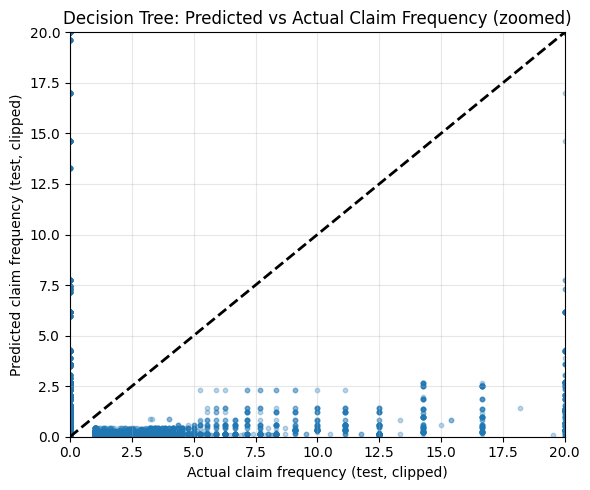

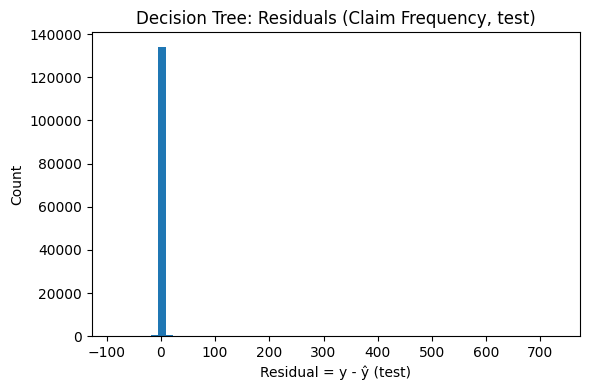

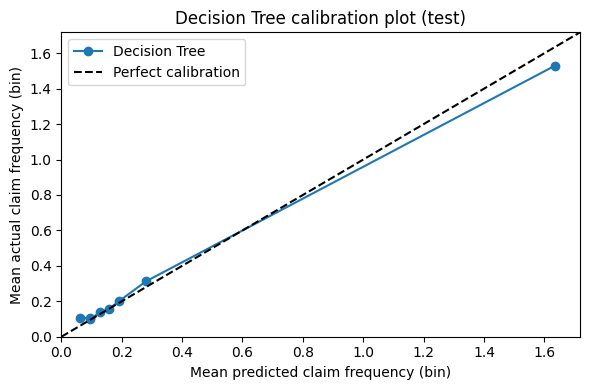

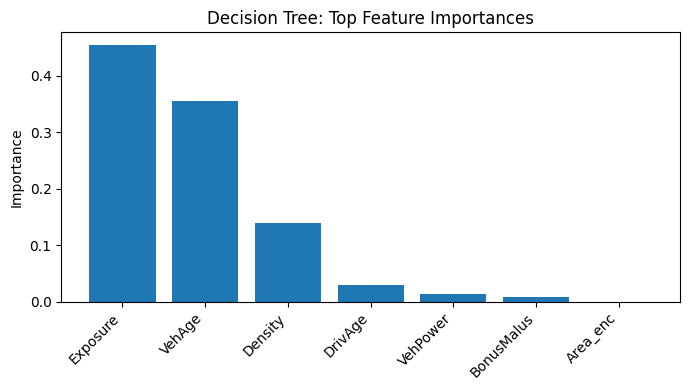

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- predictions (no refit) ---
yhat_train_tree = dt_ref.predict(X_train)
yhat_test_tree  = dt_ref.predict(X_test)

# --- RMSE on claim frequency ---
rmse_train_tree = np.sqrt(np.mean((y_train - yhat_train_tree) ** 2))
rmse_test_tree  = np.sqrt(np.mean((y_test  - yhat_test_tree)  ** 2))

print("Decision Tree RMSE (claim frequency) | train:", rmse_train_tree, "| test:", rmse_test_tree)

# 1) Predicted vs Actual (test)
clip_max = 20

y_test_clip = np.clip(y_test, 0, clip_max)
yhat_test_clip = np.clip(yhat_test_tree, 0, clip_max)

plt.figure(figsize=(6, 5))
plt.scatter(y_test_clip, yhat_test_clip, s=10, alpha=0.3)

# 45-degree reference line
plt.plot([0, clip_max], [0, clip_max], "k--", lw=2)

plt.xlim(0, clip_max)
plt.ylim(0, clip_max)

plt.xlabel("Actual claim frequency (test, clipped)")
plt.ylabel("Predicted claim frequency (test, clipped)")
plt.title("Decision Tree: Predicted vs Actual Claim Frequency (zoomed)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Residuals distribution (test)
res_tree = y_test - yhat_test_tree
plt.figure(figsize=(6, 4))
plt.hist(res_tree, bins=60)
plt.xlabel("Residual = y - ŷ (test)")
plt.ylabel("Count")
plt.title("Decision Tree: Residuals (Claim Frequency, test)")
plt.tight_layout()
plt.show()

# 3) Calibration-style plot (prediction deciles)
import numpy as np
import matplotlib.pyplot as plt

# Calibration plot settings
q = 10  # number of bins

# Predicted and true values (claim frequency)
yhat = yhat_test_tree
ytrue = y_test

# Bin by predicted quantiles
bins = np.quantile(yhat, np.linspace(0, 1, q + 1))
bin_id = np.digitize(yhat, bins[1:-1], right=True)

avg_pred = []
avg_true = []

for b in range(q):
    mask = bin_id == b
    if mask.sum() == 0:
        continue
    avg_pred.append(yhat[mask].mean())
    avg_true.append(ytrue[mask].mean())

avg_pred = np.array(avg_pred)
avg_true = np.array(avg_true)

xmin = 0.0
xmax = max(avg_pred.max(), avg_true.max()) * 1.05

plt.figure(figsize=(6, 4))
plt.plot(avg_pred, avg_true, marker="o", label="Decision Tree")
plt.plot([xmin, xmax], [xmin, xmax], "k--", label="Perfect calibration")

plt.xlim(xmin, xmax)
plt.ylim(xmin, xmax)

plt.xlabel("Mean predicted claim frequency (bin)")
plt.ylabel("Mean actual claim frequency (bin)")
plt.title("Decision Tree calibration plot (test)")
plt.legend()
plt.tight_layout()
plt.show()

# --- 4) Feature importance ---
if "feature_cols" in globals():
    importances = dt_ref.feature_importances_
    order = np.argsort(importances)[::-1]

    top_k = min(15, len(importances))
    plt.figure(figsize=(7, 4))
    plt.bar([feature_cols[i] for i in order[:top_k]], importances[order[:top_k]])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title("Decision Tree: Top Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print("feature_cols not found -> skipping feature importance plot.")


With using libraries

In [16]:
import numpy as np
#baseline:
baseline_pred_train = np.full_like(y_train, y_train.mean(), dtype=float)

if y_test is not None:
    baseline_pred_test = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_train_rmse = np.sqrt(np.mean((y_train - baseline_pred_train) ** 2))
print("Baseline train RMSE:", baseline_train_rmse)

if y_test is not None:
    baseline_test_rmse = np.sqrt(np.mean((y_test - baseline_pred_test) ** 2))
    print("Baseline test RMSE:", baseline_test_rmse)


Baseline train RMSE: 4.432150285293836
Baseline test RMSE: 5.208937177703782


In [8]:
from sklearn.tree import DecisionTreeRegressor

#hyperparameters
dt_ref = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42
)

dt_ref.fit(X_train, y_train)

y_pred_train_ref = dt_ref.predict(X_train)
if y_test is not None:
    y_pred_test_ref = dt_ref.predict(X_test)

train_rmse_ref = np.sqrt(np.mean((y_train - y_pred_train_ref) ** 2))
print("sklearn tree train RMSE:", train_rmse_ref)

if y_test is not None:
    test_rmse_ref = np.sqrt(np.mean((y_test - y_pred_test_ref) ** 2))
    print("sklearn tree test RMSE:", test_rmse_ref)


sklearn tree train RMSE: 4.23558984247776
sklearn tree test RMSE: 5.001105007077319


In [9]:
n_show = 10

print("idx | y_true | y_pred_scratch | y_pred_sklearn")
for i in range(n_show):
    print(
        i,
        float(y_test[i]),
        float(y_pred_test[i]),
        float(y_pred_test_ref[i])
    )


idx | y_true | y_pred_scratch | y_pred_sklearn
0 0.0 0.22546824262219908 0.06209682209846871
1 0.0 0.22546824262219908 0.1576885637865833
2 0.0 0.22546824262219908 0.38618130537468526
3 0.0 0.22546824262219908 0.4940763208890958
4 0.0 0.22546824262219908 0.23682411186166502
5 0.0 0.22546824262219908 0.06209682209846871
6 0.0 0.22546824262219908 0.3074692876160873
7 0.0 0.22546824262219908 0.09550194527516254
8 0.0 0.22546824262219908 0.09550194527516254
9 0.0 0.22546824262219908 0.42162385373623246


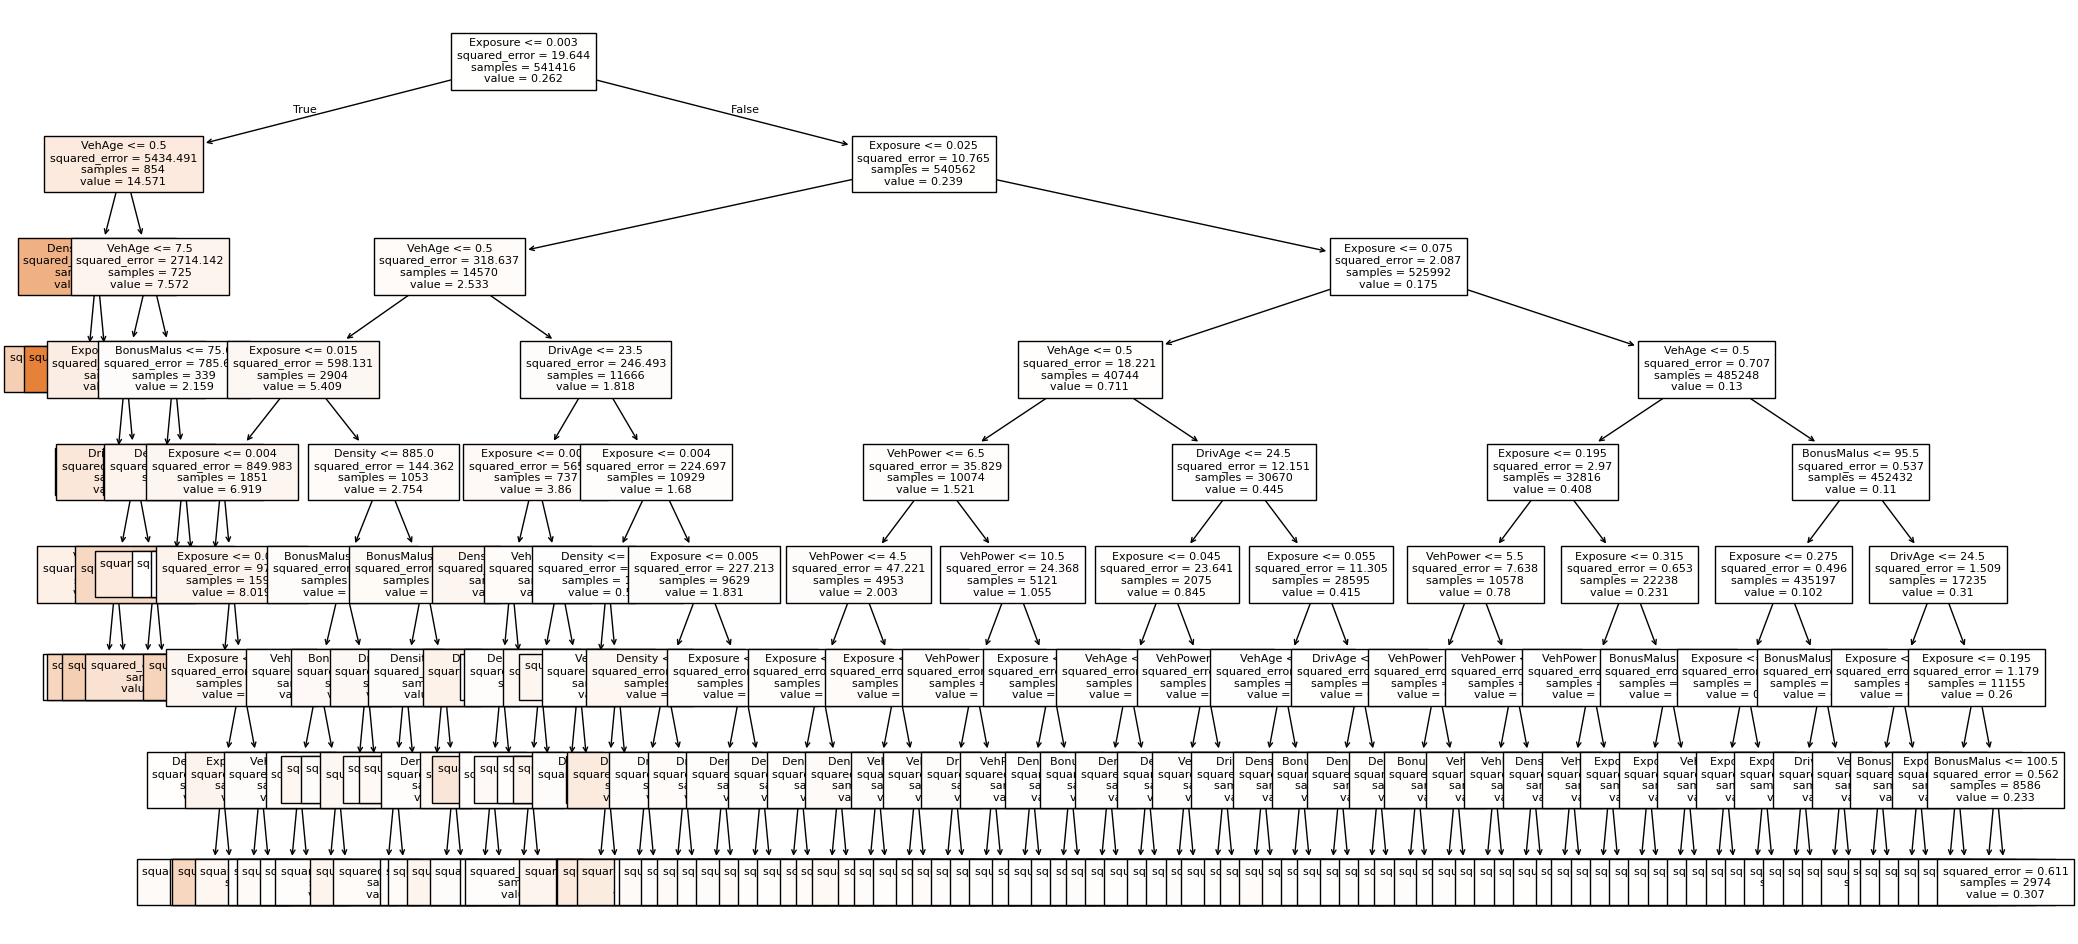

In [17]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 12))
tree.plot_tree(dt_ref, feature_names=feature_cols, filled=True, fontsize=8)
plt.show()


In [18]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

depth_values = [4, 6, 8, 10]
min_split_values = [20, 50, 100]
min_leaf_values = [10, 20, 50]

results = []

for depth in depth_values:
    for min_split in min_split_values:
        for min_leaf in min_leaf_values:

            #define the model with given hyperparameters
            dt = DecisionTreeRegressor(
                criterion="squared_error",
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )

            #fit the model
            dt.fit(X_train, y_train)

            #predictions on train and test
            pred_train = dt.predict(X_train)
            pred_test  = dt.predict(X_test)

            #RMSE
            rmse_train = np.sqrt(np.mean((y_train - pred_train)**2))
            rmse_test  = np.sqrt(np.mean((y_test  - pred_test )**2))

            results.append((depth, min_split, min_leaf, rmse_train, rmse_test))

            print(
                "depth =", depth,
                "| min_split =", min_split,
                "| min_leaf =", min_leaf,
                "| train_RMSE =", round(rmse_train, 6),
                "| test_RMSE =", round(rmse_test, 6)
            )


depth = 4 | min_split = 20 | min_leaf = 10 | train_RMSE = 4.24832 | test_RMSE = 4.98031
depth = 4 | min_split = 20 | min_leaf = 20 | train_RMSE = 4.241958 | test_RMSE = 4.971715
depth = 4 | min_split = 20 | min_leaf = 50 | train_RMSE = 4.286211 | test_RMSE = 4.999794
depth = 4 | min_split = 50 | min_leaf = 10 | train_RMSE = 4.24832 | test_RMSE = 4.98031
depth = 4 | min_split = 50 | min_leaf = 20 | train_RMSE = 4.253629 | test_RMSE = 4.97243
depth = 4 | min_split = 50 | min_leaf = 50 | train_RMSE = 4.286211 | test_RMSE = 4.999794
depth = 4 | min_split = 100 | min_leaf = 10 | train_RMSE = 4.263217 | test_RMSE = 4.99907
depth = 4 | min_split = 100 | min_leaf = 20 | train_RMSE = 4.268507 | test_RMSE = 4.99122
depth = 4 | min_split = 100 | min_leaf = 50 | train_RMSE = 4.286211 | test_RMSE = 4.999794
depth = 6 | min_split = 20 | min_leaf = 10 | train_RMSE = 4.184244 | test_RMSE = 4.99958
depth = 6 | min_split = 20 | min_leaf = 20 | train_RMSE = 4.212118 | test_RMSE = 4.988656
depth = 6 | min

In [21]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "min_samples_split", "min_samples_leaf",
             "train_RMSE", "test_RMSE"]
)

# sort by test RMSE (ascending -> best first)
results_df.sort_values("test_RMSE").head(10)


,max_depth,min_samples_split,min_samples_leaf,train_RMSE,test_RMSE
16,6,100,20,4.245799,4.962382
25,8,100,20,4.220258,4.965655
34,10,100,20,4.206712,4.969977
1,4,20,20,4.241958,4.971715
4,4,50,20,4.253629,4.972430
15,6,100,10,4.234406,4.975270
19,8,20,20,4.169010,4.979676
0,4,20,10,4.248320,4.980310
3,4,50,10,4.248320,4.980310
22,8,50,20,4.184548,4.983712
